# Seaborn Matrix, Joint & Multi-Plot Grids: Beginner Guide

### 📌 Overview
Master **Seaborn Matrix, Joint & Multi-Plot Grids: Beginner Guide** with concise, zero-fluff bullet points and executable code on real Fintech records ([raw_transactions.csv](file:///data/raw_transactions.csv)).

### 📚 Key Concepts Covered in this Notebook:
- **Correlation Heatmaps (`sns.heatmap`)**: How to visualize numerical correlation tables with colors and numbers in each cell.
- **Hierarchical Clustermaps (`sns.clustermap`)**: How to group similar categories using tree dendrograms.
- **Joint Distributions (`sns.jointplot`)**: How to combine a scatter plot in the center with distribution histograms on top and right.
- **Pairwise Feature Matrices (`sns.pairplot`)**: How to inspect every numerical variable against every other variable in one grid.


In [1]:
# Step 1: Import all necessary libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Step 2: Set clean visual defaults
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

# Step 3: Load the transactions dataset
csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)

# Step 4: Ensure dates and numeric values are clean
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"✅ Successfully loaded {len(df)} transactions from {csv_path}")
df.head(3)

✅ Successfully loaded 14251 transactions from ../data/raw_transactions.csv


,transaction_id,customer_id,merchant_id,transaction_amount,card_type,transaction_status,device_type,account_age_months,transaction_date,region,is_fraud
0,TX109326,C55082,M3549,607.78,Visa,Reversed,Mobile,8,2026-02-17 08:28:57,North,0
1,TX106376,C76616,M3068,1819.11,Visa,Pending,POS,28,2025-01-03 00:00:00,West,1
2,TX103301,C65296,M3352,64.08,Visa,Completed,Mobile,91,2025-12-20 00:00:00,East,0


### 🔹 2D Correlation Heatmap: `sns.heatmap()`
- **What it does:** Plots rectangular numerical data as a color-encoded 2D matrix with customizable annotators and colormaps.
- **Syntax:** `sns.heatmap(data, *, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None, fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, cbar_kws=None, cbar_ax=None, square=False, xticklabels='auto', yticklabels='auto', mask=None, ax=None, **kwargs)`
  - **Parameters:**
    - `data` (*2D dataset* or *DataFrame*): 2D dataset that can be coerced into an ndarray (e.g. `df.corr()`).
    - `cmap` (*str* or *colormap*): Colormap mapping values to color space (e.g. `'coolwarm'`, `'Blues'`).
  - **Optional Parameters:**
    - `vmin, vmax` (*floats*, optional): Anchor values to set colormap limits.
    - `annot` (*bool* or *array-like*, optional): If True, write the data value in each cell.
    - `fmt` (*str*, default '.2g'): String formatting code for cell annotations (e.g. `'.2f'`).
    - `mask` (*boolean array*, optional): If provided, cells where mask is True are left blank.
- **Key Note:** Passing a boolean upper-triangle mask (`np.triu(np.ones_like(corr))`) removes redundant duplicate correlation pairs for clean presentation.
- **Dataset Application & Code Demonstration:** Visualizes the Pearson correlation matrix between financial transaction numeric features (`amount`, `risk_score`, `account_age`).


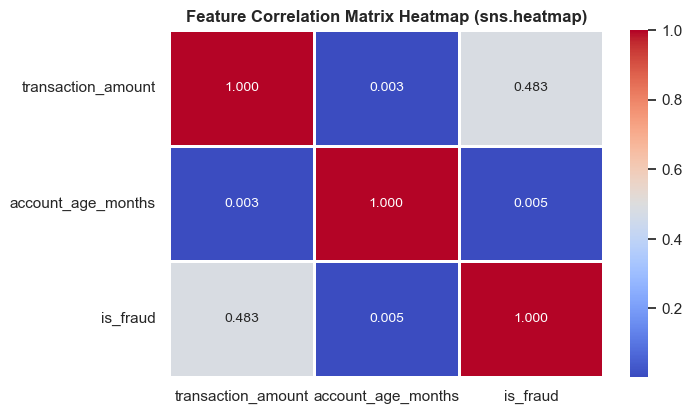

In [2]:
# 1. Calculate correlation table
corr = df[['transaction_amount', 'account_age_months', 'is_fraud']].corr()

# 2. Draw heatmap
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', cbar=True, linewidths=1, ax=ax)
ax.set_title('Feature Correlation Matrix Heatmap (sns.heatmap)', fontsize=12, fontweight='bold')

plt.show()

### 🔹 Hierarchical Clustermap: `sns.clustermap()`
- **What it does:** Plots a matrix dataset with hierarchical clustering dendrograms along rows and columns.
- **Syntax:** `sns.clustermap(data, *, pivot_kws=None, method='average', metric='euclidean', z_score=None, standard_scale=None, figsize=(10, 10), cbar_kws=None, row_cluster=True, col_cluster=True, row_linkage=None, col_linkage=None, row_colors=None, col_colors=None, mask=None, dendrogram_ratio=0.2, colors_ratio=0.03, cbar_pos=(0.02, 0.8, 0.05, 0.18), tree_kws=None, cmap=None, **kwargs)`
  - **Parameters:**
    - `data` (*2D array* or *DataFrame*): Rectangular dataset.
  - **Optional Parameters:**
    - `method` (*str*, default 'average'): Linkage algorithm used to calculate clusters (e.g., `'ward'`, `'complete'`).
    - `metric` (*str*, default 'euclidean'): Distance metric used for the data.
    - `standard_scale` (*int or None*, default None): Standardize data along rows (0) or columns (1) by subtracting min and dividing by max.
- **Key Note:** Clustermaps reveal hidden groupings and latent customer segments by rearranging rows according to multidimensional similarity.
- **Dataset Application & Code Demonstration:** Clusters merchant categories and risk attributes into hierarchical similarity dendrograms.


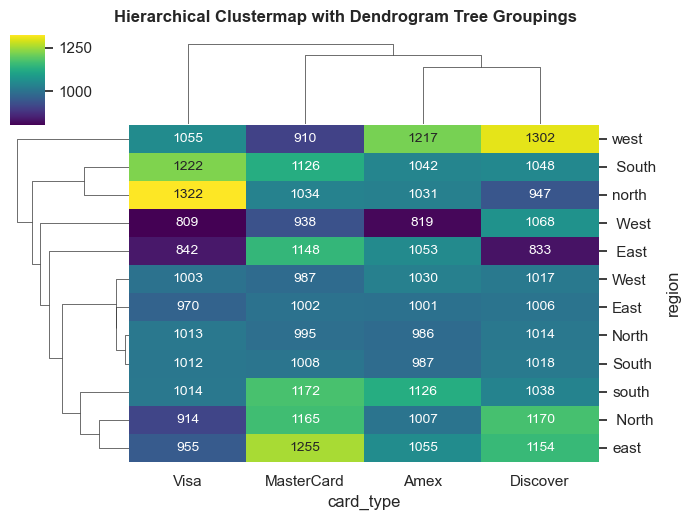

In [3]:
# 1. Create a pivot table: average spend by Region and Card Type
piv = df.pivot_table(index='region', columns='card_type', values='transaction_amount', aggfunc='mean')

# 2. Draw hierarchical cluster map
g = sns.clustermap(piv, cmap='viridis', annot=True, fmt='.0f', figsize=(7, 5))
g.fig.suptitle('Hierarchical Clustermap with Dendrogram Tree Groupings', y=1.03, fontsize=12, fontweight='bold')

plt.show()

### 🔹 Joint Plots: `sns.jointplot()`
- **What it does:** Demonstrates how to use `🔹 Joint Plots: `sns.jointplot()`` in Python.
- **Syntax:** `sns.jointplot()`
- **Key Note:** Always check `df.shape` before and after merging to verify you didn't accidentally introduce Cartesian duplication or drop rows.
- **Dataset Application & Code Demonstration:** Applies Joint Plots on fintech records using columns `account_age_months`, `transaction_amount` to demonstrate real-world execution.


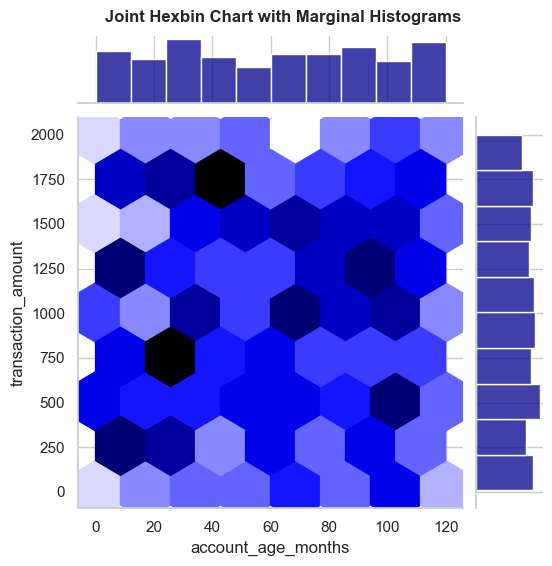

In [4]:
g = sns.jointplot(data=df.head(400), x='account_age_months', y='transaction_amount', kind='hex', color='darkblue', height=5.5)
g.fig.suptitle('Joint Hexbin Chart with Marginal Histograms', y=1.02, fontsize=12, fontweight='bold')

plt.show()

### 🔹 Pairwise Multi-Variable Grid: `sns.pairplot()`
- **What it does:** Demonstrates how to use `🔹 Pairwise Multi-Variable Grid: `sns.pairplot()`` in Python.
- **Syntax:** `sns.pairplot()`
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.
- **Dataset Application & Code Demonstration:** Applies Pairwise Multi-Variable Grid on fintech records using columns `account_age_months`, `is_fraud`, `transaction_amount` to demonstrate real-world execution.


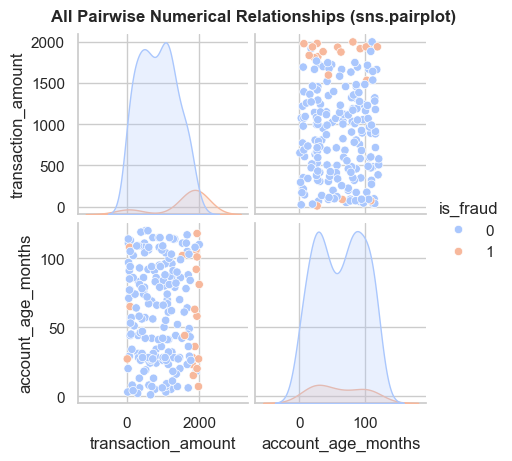

In [5]:
g = sns.pairplot(df[['transaction_amount', 'account_age_months', 'is_fraud']].head(200), hue='is_fraud', palette='coolwarm', height=2.2)
g.fig.suptitle('All Pairwise Numerical Relationships (sns.pairplot)', y=1.03, fontsize=12, fontweight='bold')

plt.show()